# Chapter 5: Linear Systems

**Book:** *Linear Algebra with Applications in Machine Learning: From Intuitive Understanding to Python Coding*

---

Linear systems are where linear algebra meets problem-solving. The equation $A\mathbf{x} = \mathbf{b}$ encodes constraints, models, and relationships that underpin everything from regression to neural network training. This notebook covers:

1. **Systems of Linear Equations** — definition, matrix form, unique/no/infinite solutions
2. **Linear Combinations** — constructing vectors, consistency of systems
3. **Span** — reachable vectors, subspaces, column space
4. **Linear Dependence and Independence** — redundancy, basis, RREF
5. **Solving Methods** — substitution, elimination, Gaussian elimination
6. **Matrix Rank and Solutions** — rank, nullity, Rank-Nullity Theorem
7. **Linear Systems in ML** — linear regression, normal equations, feature engineering

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import sympy as sp

plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 12
np.set_printoptions(precision=4, suppress=True)

print("All imports successful.")

All imports successful.


## 5.1 Systems of Linear Equations: Definition and Basics

A system of $m$ linear equations in $n$ unknowns is written compactly as:

$$A\mathbf{x} = \mathbf{b}$$

where $A \in \mathbb{R}^{m \times n}$ is the coefficient matrix, $\mathbf{x} \in \mathbb{R}^n$ is the unknown vector, and $\mathbf{b} \in \mathbb{R}^m$ is the constant vector.

Geometrically, each equation defines a hyperplane. The solution set is their intersection, which can be:
- **A single point** (unique solution)
- **Empty** (no solution, inconsistent)
- **A line, plane, or higher-dimensional subspace** (infinitely many solutions)

### 5.1.1 Unique Solution

A square system $A\mathbf{x} = \mathbf{b}$ with $\det(A) \neq 0$ has exactly one solution: $\mathbf{x} = A^{-1}\mathbf{b}$.

In [2]:
# System: 3x1 - x2 = 10,  x1 - 3x2 = 0
A = np.array([[3, -1],
              [1, -3]])
b = np.array([10, 0])

x = np.linalg.solve(A, b)
print(f"Solution: x1 = {x[0]}, x2 = {x[1]}")

# Verify
print(f"Verification: A @ x = {A @ x}  (should be {b})")
print(f"det(A) = {np.linalg.det(A):.4f}  (nonzero => unique solution)")

Solution: x1 = 3.75, x2 = 1.25
Verification: A @ x = [10.  0.]  (should be [10  0])
det(A) = -8.0000  (nonzero => unique solution)


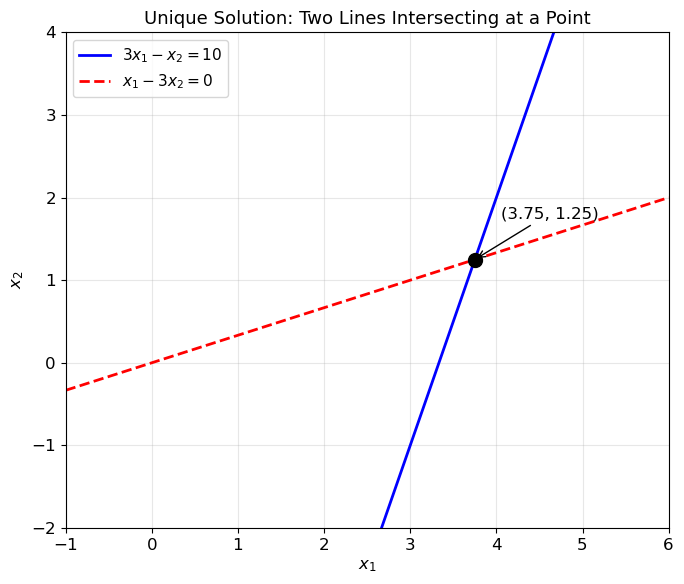

In [3]:
# Visualize: two lines intersecting at a point
fig, ax = plt.subplots(figsize=(7, 6))
x1_range = np.linspace(-1, 6, 300)

# Line 1: 3x1 - x2 = 10  =>  x2 = 3x1 - 10
x2_line1 = 3 * x1_range - 10
# Line 2: x1 - 3x2 = 0   =>  x2 = x1/3
x2_line2 = x1_range / 3

ax.plot(x1_range, x2_line1, 'b-', linewidth=2, label=r'$3x_1 - x_2 = 10$')
ax.plot(x1_range, x2_line2, 'r--', linewidth=2, label=r'$x_1 - 3x_2 = 0$')
ax.plot(x[0], x[1], 'ko', markersize=10, zorder=5)
ax.annotate(f'({x[0]:.2f}, {x[1]:.2f})', xy=(x[0], x[1]),
            xytext=(x[0]+0.3, x[1]+0.5), fontsize=12,
            arrowprops=dict(arrowstyle='->', color='black'))

ax.set_xlim(-1, 6)
ax.set_ylim(-2, 4)
ax.set_xlabel(r'$x_1$')
ax.set_ylabel(r'$x_2$')
ax.set_title('Unique Solution: Two Lines Intersecting at a Point', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 5.1.2 No Solution (Inconsistent System)

When the equations represent parallel hyperplanes (same slope, different intercepts), they never intersect.

In [4]:
# System: 3x1 + x2 = 10,  6x1 + 2x2 = 0  (second is 2x first, but RHS differs)
A_inc = np.array([[3, 1],
                  [6, 2]])
b_inc = np.array([10, 0])

print(f"det(A) = {np.linalg.det(A_inc):.6f}  (zero => singular, no unique solution)")
print(f"rank(A) = {np.linalg.matrix_rank(A_inc)}")
print(f"rank([A|b]) = {np.linalg.matrix_rank(np.column_stack([A_inc, b_inc]))}")
print("rank(A) < rank([A|b]) => INCONSISTENT (no solution)")

try:
    np.linalg.solve(A_inc, b_inc)
except np.linalg.LinAlgError:
    print("\nnp.linalg.solve raises LinAlgError for singular matrix.")

det(A) = 0.000000  (zero => singular, no unique solution)
rank(A) = 1
rank([A|b]) = 2
rank(A) < rank([A|b]) => INCONSISTENT (no solution)

np.linalg.solve raises LinAlgError for singular matrix.


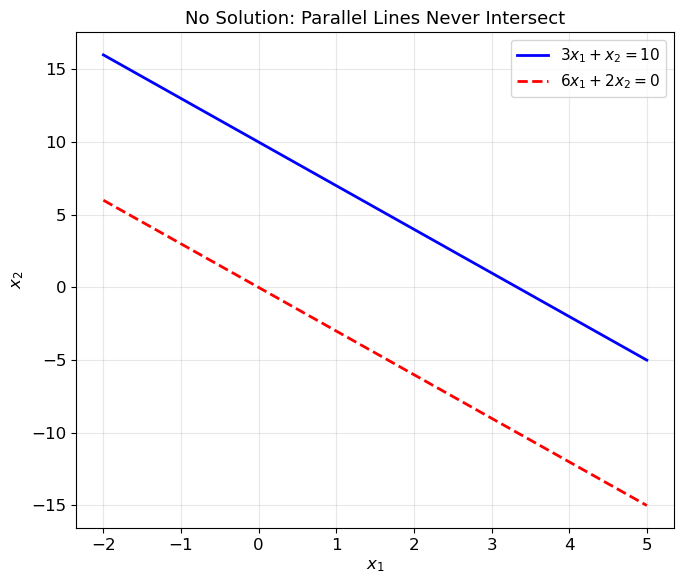

In [5]:
# Visualize parallel lines
fig, ax = plt.subplots(figsize=(7, 6))
x1_range = np.linspace(-2, 5, 300)

ax.plot(x1_range, -3*x1_range + 10, 'b-', linewidth=2, label=r'$3x_1 + x_2 = 10$')
ax.plot(x1_range, -3*x1_range, 'r--', linewidth=2, label=r'$6x_1 + 2x_2 = 0$')

ax.set_xlabel(r'$x_1$')
ax.set_ylabel(r'$x_2$')
ax.set_title('No Solution: Parallel Lines Never Intersect', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 5.1.3 Infinitely Many Solutions

When there are fewer independent equations than unknowns, some variables are free and the solution forms a line, plane, or higher-dimensional subspace.

In [6]:
# System: 2x1 - 3x2 + x3 = -10,  x1 + x3 = 3
# 2 equations, 3 unknowns => underdetermined
A_under = np.array([[2, -3, 1],
                    [1,  0, 1]])
b_under = np.array([-10, 3])

print(f"A shape: {A_under.shape}  (2 equations, 3 unknowns)")
print(f"rank(A) = {np.linalg.matrix_rank(A_under)}")
print(f"rank([A|b]) = {np.linalg.matrix_rank(np.column_stack([A_under, b_under]))}")
print("rank(A) = rank([A|b]) = 2 < 3 unknowns => infinitely many solutions")

# Parametric solution: x1 = t, x2 = (t+13)/3, x3 = 3-t
print("\nParametric solution: x1 = t, x2 = (t+13)/3, x3 = 3-t")
for t in [-4, 0, 2, 5]:
    sol = np.array([t, (t + 13)/3, 3 - t])
    residual = A_under @ sol - b_under
    print(f"  t={t:3d}: x = [{sol[0]:6.2f}, {sol[1]:6.2f}, {sol[2]:6.2f}]  "
          f"residual = {residual}")

A shape: (2, 3)  (2 equations, 3 unknowns)
rank(A) = 2
rank([A|b]) = 2
rank(A) = rank([A|b]) = 2 < 3 unknowns => infinitely many solutions

Parametric solution: x1 = t, x2 = (t+13)/3, x3 = 3-t
  t= -4: x = [ -4.00,   3.00,   7.00]  residual = [0. 0.]
  t=  0: x = [  0.00,   4.33,   3.00]  residual = [0. 0.]
  t=  2: x = [  2.00,   5.00,   1.00]  residual = [0. 0.]
  t=  5: x = [  5.00,   6.00,  -2.00]  residual = [0. 0.]


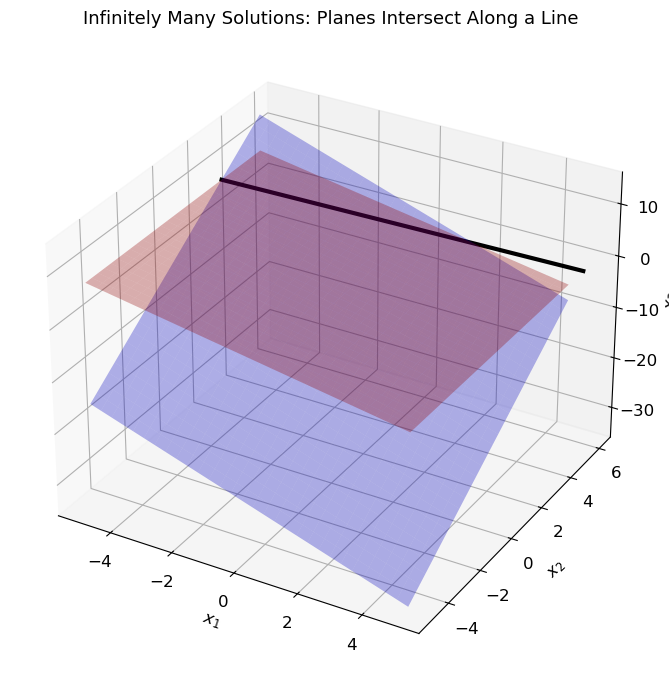

In [7]:
# Visualize: two planes intersecting along a line in R^3
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

x1_grid = np.linspace(-5, 5, 30)
x2_grid = np.linspace(-5, 5, 30)
X1, X2 = np.meshgrid(x1_grid, x2_grid)

# Plane 1: 2x1 - 3x2 + x3 = -10  =>  x3 = -10 - 2x1 + 3x2
X3_plane1 = -10 - 2*X1 + 3*X2
# Plane 2: x1 + x3 = 3  =>  x3 = 3 - x1
X3_plane2 = 3 - X1

ax.plot_surface(X1, X2, X3_plane1, alpha=0.3, color='blue', label='Plane 1')
ax.plot_surface(X1, X2, X3_plane2, alpha=0.3, color='red', label='Plane 2')

# Intersection line: parametric
t_line = np.linspace(-5, 5, 100)
ax.plot(t_line, (t_line + 13)/3, 3 - t_line, 'k-', linewidth=3, label='Solution line')

ax.set_xlabel(r'$x_1$')
ax.set_ylabel(r'$x_2$')
ax.set_zlabel(r'$x_3$')
ax.set_title('Infinitely Many Solutions: Planes Intersect Along a Line', fontsize=13)
plt.tight_layout()
plt.show()

### All Three Cases Side by Side

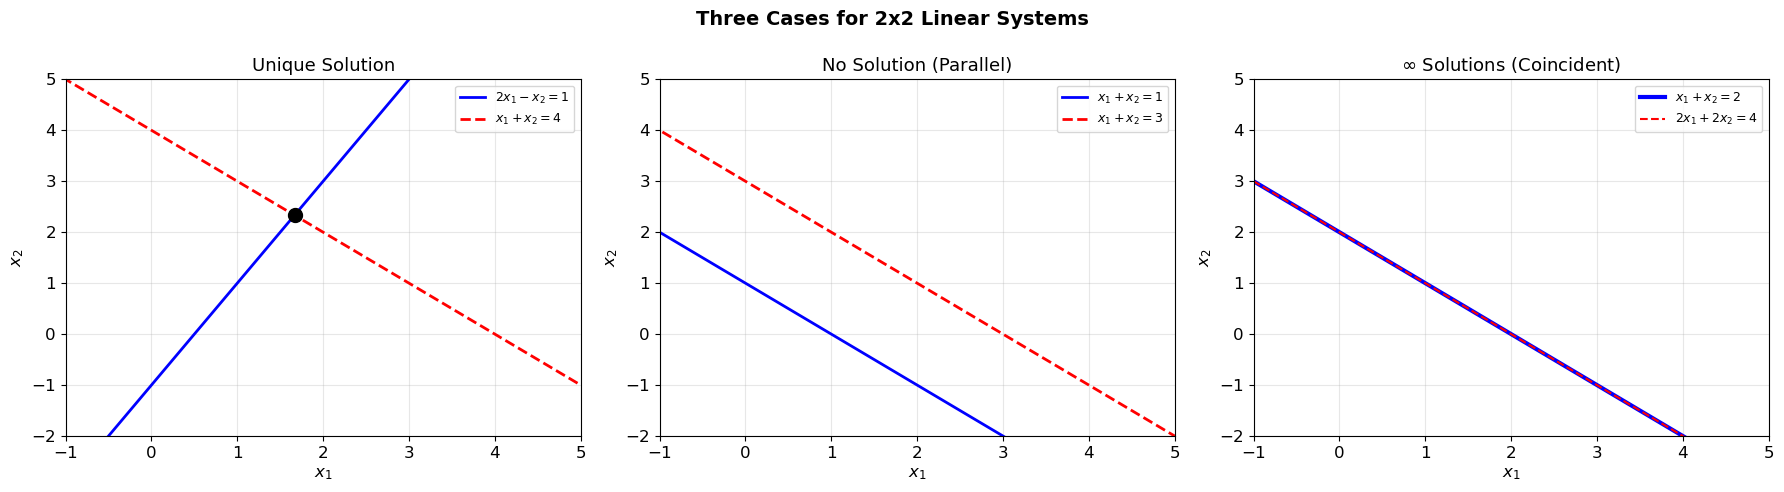

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
x_range = np.linspace(-2, 5, 300)

# Case 1: Unique solution
ax = axes[0]
ax.plot(x_range, 2*x_range - 1, 'b-', linewidth=2, label=r'$2x_1 - x_2 = 1$')
ax.plot(x_range, -x_range + 4, 'r--', linewidth=2, label=r'$x_1 + x_2 = 4$')
# Solve: x1 = 5/3, x2 = 7/3
ax.plot(5/3, 7/3, 'ko', markersize=10)
ax.set_title('Unique Solution', fontsize=13)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xlim(-1, 5)
ax.set_ylim(-2, 5)

# Case 2: No solution (parallel)
ax = axes[1]
ax.plot(x_range, -x_range + 1, 'b-', linewidth=2, label=r'$x_1 + x_2 = 1$')
ax.plot(x_range, -x_range + 3, 'r--', linewidth=2, label=r'$x_1 + x_2 = 3$')
ax.set_title('No Solution (Parallel)', fontsize=13)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xlim(-1, 5)
ax.set_ylim(-2, 5)

# Case 3: Infinitely many (coincident)
ax = axes[2]
ax.plot(x_range, -x_range + 2, 'b-', linewidth=3, label=r'$x_1 + x_2 = 2$')
ax.plot(x_range, -x_range + 2, 'r--', linewidth=1.5, label=r'$2x_1 + 2x_2 = 4$')
ax.set_title(r'$\infty$ Solutions (Coincident)', fontsize=13)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xlim(-1, 5)
ax.set_ylim(-2, 5)

for ax in axes:
    ax.set_xlabel(r'$x_1$')
    ax.set_ylabel(r'$x_2$')

plt.suptitle('Three Cases for 2x2 Linear Systems', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 5.2 Linear Combinations

A **linear combination** of vectors $\mathbf{v}_1, \dots, \mathbf{v}_n$ with scalars $c_1, \dots, c_n$ is:

$$c_1 \mathbf{v}_1 + c_2 \mathbf{v}_2 + \cdots + c_n \mathbf{v}_n$$

The system $A\mathbf{x} = \mathbf{b}$ is consistent if and only if $\mathbf{b}$ is a linear combination of the columns of $A$.

In [9]:
# Linear combination: -3*v1 + 4*v2 + 1*v3
v1 = np.array([1, 1])
v2 = np.array([1, 3])
v3 = np.array([1, -1])
coeffs = np.array([-3, 4, 1])

result = coeffs[0]*v1 + coeffs[1]*v2 + coeffs[2]*v3
print(f"Linear combination: {coeffs[0]}*{v1} + {coeffs[1]}*{v2} + {coeffs[2]}*{v3} = {result}")

# Equivalent matrix form: A @ x
A = np.column_stack([v1, v2, v3])
print(f"\nMatrix form: A @ c = {A @ coeffs}  (same result)")

Linear combination: -3*[1 1] + 4*[1 3] + 1*[ 1 -1] = [2 8]

Matrix form: A @ c = [2 8]  (same result)


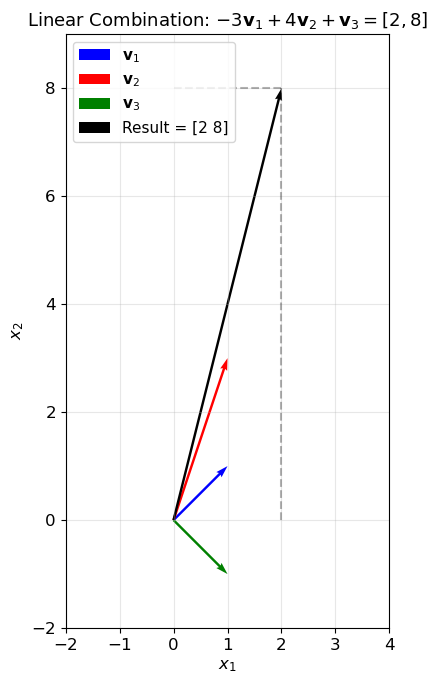

In [10]:
# Visualize the linear combination
fig, ax = plt.subplots(figsize=(7, 7))

vectors = [(v1, 'blue', r'$\mathbf{v}_1$'), (v2, 'red', r'$\mathbf{v}_2$'),
           (v3, 'green', r'$\mathbf{v}_3$')]
for v, color, label in vectors:
    ax.quiver(0, 0, v[0], v[1], angles='xy', scale_units='xy', scale=1,
              color=color, linewidth=2, label=label)

ax.quiver(0, 0, result[0], result[1], angles='xy', scale_units='xy', scale=1,
          color='black', linewidth=2.5, label=f'Result = {result}')

# Projection lines for result
ax.plot([result[0], result[0]], [0, result[1]], 'k--', alpha=0.3)
ax.plot([0, result[0]], [result[1], result[1]], 'k--', alpha=0.3)

ax.set_xlim(-2, 4)
ax.set_ylim(-2, 9)
ax.set_aspect('equal')
ax.set_xlabel(r'$x_1$')
ax.set_ylabel(r'$x_2$')
ax.set_title(r'Linear Combination: $-3\mathbf{v}_1 + 4\mathbf{v}_2 + \mathbf{v}_3 = [2, 8]$', fontsize=13)
ax.legend(loc='upper left', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Linear Combination and Inconsistency

If $\mathbf{b}$ is not in the column space of $A$, the system $A\mathbf{x} = \mathbf{b}$ has no solution. This happens when the columns of $A$ are linearly dependent and $\mathbf{b}$ lies outside their span.

rank(A) = 1
rank([A|b]) = 2
Ranks differ => b is NOT in the column space => inconsistent


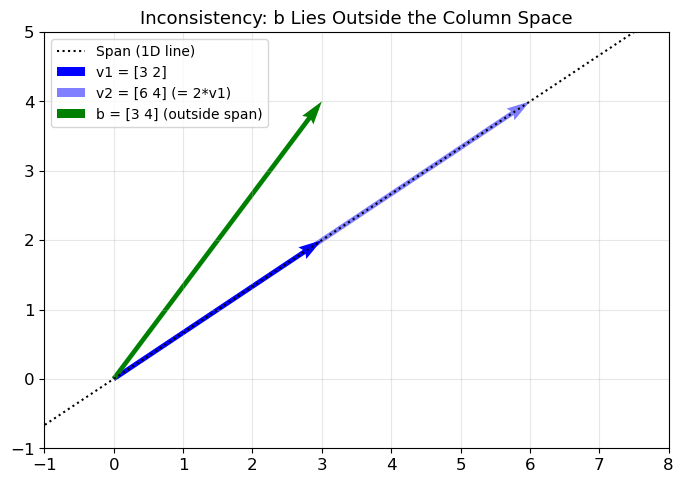

In [11]:
# v2 = 2*v1, so columns span only a line
v1 = np.array([3, 2])
v2 = np.array([6, 4])  # = 2 * v1
b_target = np.array([3, 4])  # NOT on the line y = (2/3)x

A = np.column_stack([v1, v2])
print(f"rank(A) = {np.linalg.matrix_rank(A)}")
print(f"rank([A|b]) = {np.linalg.matrix_rank(np.column_stack([A, b_target]))}")
print("Ranks differ => b is NOT in the column space => inconsistent")

fig, ax = plt.subplots(figsize=(7, 6))
# Span line
t = np.linspace(-1, 3, 100)
ax.plot(t * v1[0]/np.linalg.norm(v1) * np.linalg.norm(v1),
        t * v1[1]/np.linalg.norm(v1) * np.linalg.norm(v1),
        'k:', linewidth=1.5, label='Span (1D line)')

ax.quiver(0, 0, v1[0], v1[1], angles='xy', scale_units='xy', scale=1,
          color='blue', linewidth=2, label=f'v1 = {v1}')
ax.quiver(0, 0, v2[0], v2[1], angles='xy', scale_units='xy', scale=1,
          color='blue', linewidth=2, alpha=0.5, label=f'v2 = {v2} (= 2*v1)')
ax.quiver(0, 0, b_target[0], b_target[1], angles='xy', scale_units='xy', scale=1,
          color='green', linewidth=2.5, label=f'b = {b_target} (outside span)')

ax.set_xlim(-1, 8)
ax.set_ylim(-1, 5)
ax.set_aspect('equal')
ax.set_title('Inconsistency: b Lies Outside the Column Space', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5.3 Span

The **span** of a set of vectors is the set of all their linear combinations:

$$\text{Span}(\mathbf{v}_1, \dots, \mathbf{v}_n) = \{c_1 \mathbf{v}_1 + \cdots + c_n \mathbf{v}_n \mid c_i \in \mathbb{R}\}$$

The span is always a subspace and equals the column space $\text{Col}(A)$ when the vectors are columns of $A$.

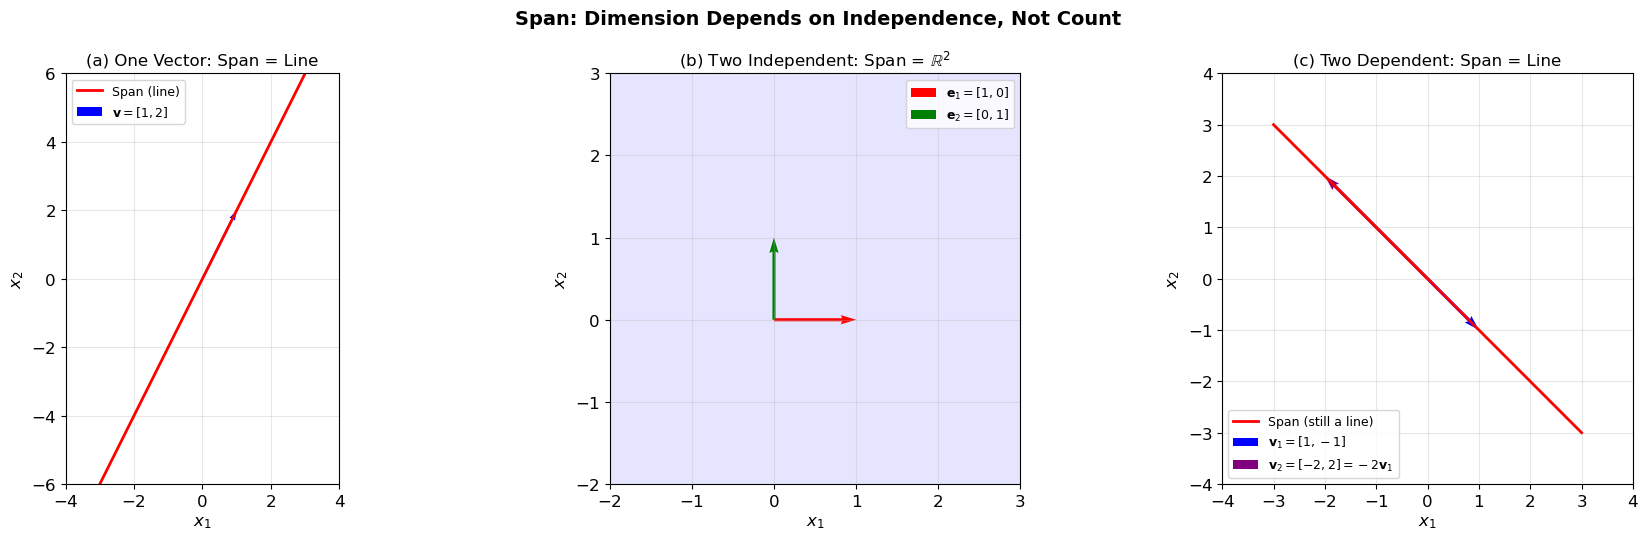

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# --- Span of 1 vector: a line ---
ax = axes[0]
v = np.array([1, 2])
t = np.linspace(-3, 3, 100)
ax.plot(t * v[0], t * v[1], 'r-', linewidth=2, label='Span (line)')
ax.quiver(0, 0, v[0], v[1], angles='xy', scale_units='xy', scale=1,
          color='blue', linewidth=2.5, label=r'$\mathbf{v} = [1, 2]$')
ax.set_xlim(-4, 4)
ax.set_ylim(-6, 6)
ax.set_aspect('equal')
ax.set_title('(a) One Vector: Span = Line', fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# --- Span of 2 independent vectors: a plane (R^2) ---
ax = axes[1]
ax.fill([-4, 4, 4, -4], [-4, -4, 4, 4], alpha=0.1, color='blue')
ax.quiver(0, 0, 1, 0, angles='xy', scale_units='xy', scale=1,
          color='red', linewidth=2.5, label=r'$\mathbf{e}_1 = [1, 0]$')
ax.quiver(0, 0, 0, 1, angles='xy', scale_units='xy', scale=1,
          color='green', linewidth=2.5, label=r'$\mathbf{e}_2 = [0, 1]$')
ax.set_xlim(-2, 3)
ax.set_ylim(-2, 3)
ax.set_aspect('equal')
ax.set_title(r'(b) Two Independent: Span = $\mathbb{R}^2$', fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# --- Span of 2 dependent vectors: still a line ---
ax = axes[2]
v1 = np.array([1, -1])
v2 = np.array([-2, 2])  # = -2*v1
t = np.linspace(-3, 3, 100)
ax.plot(t * v1[0], t * v1[1], 'r-', linewidth=2, label='Span (still a line)')
ax.quiver(0, 0, v1[0], v1[1], angles='xy', scale_units='xy', scale=1,
          color='blue', linewidth=2.5, label=r'$\mathbf{v}_1 = [1, -1]$')
ax.quiver(0, 0, v2[0], v2[1], angles='xy', scale_units='xy', scale=1,
          color='purple', linewidth=2, label=r'$\mathbf{v}_2 = [-2, 2] = -2\mathbf{v}_1$')
ax.set_xlim(-4, 4)
ax.set_ylim(-4, 4)
ax.set_aspect('equal')
ax.set_title('(c) Two Dependent: Span = Line', fontsize=12)
ax.legend(fontsize=9, loc='lower left')
ax.grid(True, alpha=0.3)

for ax in axes:
    ax.set_xlabel(r'$x_1$')
    ax.set_ylabel(r'$x_2$')

plt.suptitle('Span: Dimension Depends on Independence, Not Count', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 5.4 Linear Dependence and Independence

Vectors $\mathbf{v}_1, \dots, \mathbf{v}_n$ are **linearly independent** if the only solution to $c_1\mathbf{v}_1 + \cdots + c_n\mathbf{v}_n = \mathbf{0}$ is $c_1 = \cdots = c_n = 0$. Otherwise they are **linearly dependent** (at least one vector is a combination of the others).

Dependence implies redundancy; independence means every vector contributes a new direction.

In [13]:
def check_independence(vectors, names=None):
    """Check linear independence via matrix rank."""
    A = np.column_stack(vectors)
    n_vecs = len(vectors)
    rank = np.linalg.matrix_rank(A)
    independent = (rank == n_vecs)
    label = "INDEPENDENT" if independent else "DEPENDENT"
    name_str = ", ".join(names) if names else f"{n_vecs} vectors"
    print(f"{name_str}: rank={rank}, #vectors={n_vecs} => {label}")
    return independent

# Example 1: Dependent in R^2
v1 = np.array([2, 3])
v2 = np.array([-4, -6])  # = -2*v1
check_independence([v1, v2], ['v1=[2,3]', 'v2=[-4,-6]'])

# Example 2: Independent in R^2
v1 = np.array([1, 0])
v2 = np.array([0, 1])
check_independence([v1, v2], ['e1=[1,0]', 'e2=[0,1]'])

# Example 3: Dependent in R^3 (v3 = v1 + v2)
v1 = np.array([1, 0, 0])
v2 = np.array([0, 1, 0])
v3 = np.array([1, 1, 0])
check_independence([v1, v2, v3], ['[1,0,0]', '[0,1,0]', '[1,1,0]'])

# Example 4: Independent in R^3
v1 = np.array([1, 1, -2])
v2 = np.array([1, -1, 2])
v3 = np.array([3, 1, 4])
check_independence([v1, v2, v3], ['[1,1,-2]', '[1,-1,2]', '[3,1,4]'])

v1=[2,3], v2=[-4,-6]: rank=1, #vectors=2 => DEPENDENT
e1=[1,0], e2=[0,1]: rank=2, #vectors=2 => INDEPENDENT
[1,0,0], [0,1,0], [1,1,0]: rank=2, #vectors=3 => DEPENDENT
[1,1,-2], [1,-1,2], [3,1,4]: rank=3, #vectors=3 => INDEPENDENT


True

### Using SymPy for RREF and Dependence Analysis

SymPy's `rref()` gives exact reduced row echelon form, revealing pivot positions, free variables, and dependence relations.

In [14]:
# Dependent set: v3 = 2*v1 + v2
M = sp.Matrix([[1, 1, 3],
               [1, -1, 1],
               [1, 2, 4]])

rref_matrix, pivot_cols = M.rref()
print("Matrix (vectors as columns):")
sp.pprint(M)
print(f"\nRREF:")
sp.pprint(rref_matrix)
print(f"\nPivot columns: {pivot_cols}")
print(f"Rank: {len(pivot_cols)}, Number of vectors: {M.cols}")
if len(pivot_cols) < M.cols:
    print(f"=> DEPENDENT (column {M.cols - 1} has no pivot, it's a free variable)")

# Null space gives the dependence relation
null = M.nullspace()
print(f"\nNull space (dependence relation):")
for v in null:
    sp.pprint(v.T)
    print(f"  => {v[0]}*v1 + {v[1]}*v2 + {v[2]}*v3 = 0")

Matrix (vectors as columns):
⎡1  1   3⎤
⎢        ⎥
⎢1  -1  1⎥
⎢        ⎥
⎣1  2   4⎦

RREF:
⎡1  0  2⎤
⎢       ⎥
⎢0  1  1⎥
⎢       ⎥
⎣0  0  0⎦

Pivot columns: (0, 1)
Rank: 2, Number of vectors: 3
=> DEPENDENT (column 2 has no pivot, it's a free variable)

Null space (dependence relation):
[-2  -1  1]
  => -2*v1 + -1*v2 + 1*v3 = 0


In [15]:
# Independent set: RREF = Identity
M2 = sp.Matrix([[1, 1, 3],
                [1, -1, 1],
                [-2, 2, 4]])

rref2, pivots2 = M2.rref()
print("Matrix:")
sp.pprint(M2)
print(f"\nRREF:")
sp.pprint(rref2)
print(f"\nPivot columns: {pivots2}")
print(f"All columns are pivot columns => INDEPENDENT")

Matrix:
⎡1   1   3⎤
⎢         ⎥
⎢1   -1  1⎥
⎢         ⎥
⎣-2  2   4⎦

RREF:
⎡1  0  0⎤
⎢       ⎥
⎢0  1  0⎥
⎢       ⎥
⎣0  0  1⎦

Pivot columns: (0, 1, 2)
All columns are pivot columns => INDEPENDENT


## 5.5 Solving Methods for Linear Systems

### 5.5.1 Gaussian Elimination (via Augmented Matrix)

The most general method: form the augmented matrix $[A | \mathbf{b}]$, apply elementary row operations to reach REF or RREF, then read off the solution.

In [16]:
# Solve: 2x + 4y - 2z = 2,  4x + 9y - 3z = 8,  -2x - 3y + 7z = 10
A = np.array([[2, 4, -2],
              [4, 9, -3],
              [-2, -3, 7]], dtype=float)
b = np.array([2, 8, 10], dtype=float)

# Solve with NumPy
x_np = np.linalg.solve(A, b)
print(f"NumPy solution: {x_np}")

# Solve with SymPy (exact, showing RREF)
aug = sp.Matrix(np.column_stack([A, b]).tolist())
print("\nAugmented matrix:")
sp.pprint(aug)

rref_aug, pivots = aug.rref()
print("\nRREF:")
sp.pprint(rref_aug)
print(f"\nSolution: x = {rref_aug[0, 3]}, y = {rref_aug[1, 3]}, z = {rref_aug[2, 3]}")

NumPy solution: [-1.  2.  2.]

Augmented matrix:
⎡2.0   4.0   -2.0  2.0 ⎤
⎢                      ⎥
⎢4.0   9.0   -3.0  8.0 ⎥
⎢                      ⎥
⎣-2.0  -3.0  7.0   10.0⎦

RREF:
⎡1  0  0  -1.0⎤
⎢             ⎥
⎢0  1  0  2.0 ⎥
⎢             ⎥
⎣0  0  1  2.0 ⎦

Solution: x = -1.00000000000000, y = 2.00000000000000, z = 2.00000000000000


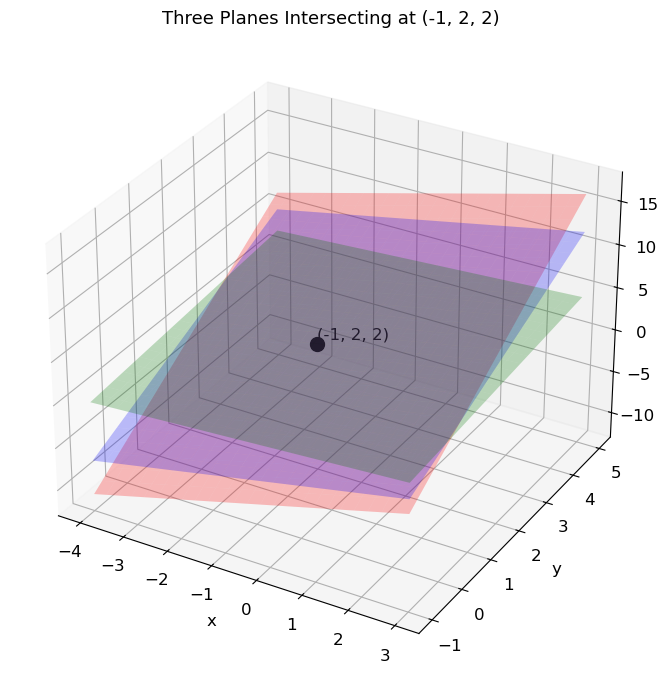

In [17]:
# Visualize: three planes intersecting at a point
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

x_grid = np.linspace(-4, 3, 25)
y_grid = np.linspace(-1, 5, 25)
X, Y = np.meshgrid(x_grid, y_grid)

# Plane 1: 2x + 4y - 2z = 2  =>  z = x + 2y - 1
Z1 = X + 2*Y - 1
# Plane 2: 4x + 9y - 3z = 8  =>  z = (4x + 9y - 8)/3
Z2 = (4*X + 9*Y - 8) / 3
# Plane 3: -2x - 3y + 7z = 10  =>  z = (-2x - 3y + 10) / (-7) ... wait
Z3 = (10 + 2*X + 3*Y) / 7

ax.plot_surface(X, Y, Z1, alpha=0.25, color='blue')
ax.plot_surface(X, Y, Z2, alpha=0.25, color='red')
ax.plot_surface(X, Y, Z3, alpha=0.25, color='green')
ax.scatter([-1], [2], [2], color='black', s=100, zorder=5)
ax.text(-1, 2, 2.5, '(-1, 2, 2)', fontsize=12)

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.set_title('Three Planes Intersecting at (-1, 2, 2)', fontsize=13)
plt.tight_layout()
plt.show()

### 5.5.2 Special Case: Infinite Solutions with Free Variables

In [18]:
# System with free variables: pivots in cols 0, 2, 4; free cols 1, 3
# x1 - 3*x2 + 2*x4 = 7,  x3 + 6*x4 = 9,  x5 = 2
aug = sp.Matrix([
    [1, -3, 0, 2, 0, 7],
    [0, 0, 1, 6, 0, 9],
    [0, 0, 0, 0, 1, 2]
])

print("Augmented matrix (already in REF):")
sp.pprint(aug)
print("\nPivot columns: 0, 2, 4")
print("Free variables: x2 = s, x4 = t")
print("\nGeneral solution:")
print("  x1 = 7 + 3s - 2t")
print("  x2 = s")
print("  x3 = 9 - 6t")
print("  x4 = t")
print("  x5 = 2")

# Generate specific solutions
print("\nSample solutions:")
for s, t in [(0, 0), (1, 0), (0, 1), (2, -1)]:
    x = [7 + 3*s - 2*t, s, 9 - 6*t, t, 2]
    print(f"  s={s}, t={t}: x = {x}")

Augmented matrix (already in REF):
⎡1  -3  0  2  0  7⎤
⎢                 ⎥
⎢0  0   1  6  0  9⎥
⎢                 ⎥
⎣0  0   0  0  1  2⎦

Pivot columns: 0, 2, 4
Free variables: x2 = s, x4 = t

General solution:
  x1 = 7 + 3s - 2t
  x2 = s
  x3 = 9 - 6t
  x4 = t
  x5 = 2

Sample solutions:
  s=0, t=0: x = [7, 0, 9, 0, 2]
  s=1, t=0: x = [10, 1, 9, 0, 2]
  s=0, t=1: x = [5, 0, 3, 1, 2]
  s=2, t=-1: x = [15, 2, 15, -1, 2]


### 5.5.3 Special Case: No Solution (Contradiction Row)

In [19]:
# x1 + x2 = 1,  x1 + x2 = 2  =>  0 = 1 after elimination
aug_inc = sp.Matrix([
    [1, 1, 1],
    [1, 1, 2]
])

print("Augmented matrix:")
sp.pprint(aug_inc)

rref_inc, _ = aug_inc.rref()
print("\nRREF:")
sp.pprint(rref_inc)
print("\nRow [0, 0 | 1] means 0 = 1, a contradiction => NO SOLUTION")

Augmented matrix:
⎡1  1  1⎤
⎢       ⎥
⎣1  1  2⎦

RREF:
⎡1  1  0⎤
⎢       ⎥
⎣0  0  1⎦

Row [0, 0 | 1] means 0 = 1, a contradiction => NO SOLUTION


### Step-by-Step Gaussian Elimination

Let us trace through the row operations manually for a 2x2 system.

In [20]:
# Solve: x + 2y = 5,  3x - y = 2  (step by step)
aug = sp.Matrix([
    [1, 2, 5],
    [3, -1, 2]
])
print("Step 0: Augmented matrix")
sp.pprint(aug)

# Step 1: R2 <- R2 - 3*R1
aug_s1 = aug.copy()
aug_s1[1, :] = aug_s1[1, :] - 3 * aug_s1[0, :]
print("\nStep 1: R2 <- R2 - 3*R1")
sp.pprint(aug_s1)

# Step 2: R2 <- R2 / (-7)
aug_s2 = aug_s1.copy()
aug_s2[1, :] = aug_s2[1, :] / (-7)
print("\nStep 2: R2 <- R2 / (-7)")
sp.pprint(aug_s2)

# Step 3: R1 <- R1 - 2*R2
aug_s3 = aug_s2.copy()
aug_s3[0, :] = aug_s3[0, :] - 2 * aug_s3[1, :]
print("\nStep 3: R1 <- R1 - 2*R2  (RREF)")
sp.pprint(aug_s3)

print(f"\nSolution: x = {aug_s3[0, 2]}, y = {aug_s3[1, 2]}")

Step 0: Augmented matrix
⎡1  2   5⎤
⎢        ⎥
⎣3  -1  2⎦

Step 1: R2 <- R2 - 3*R1
⎡1  2    5 ⎤
⎢          ⎥
⎣0  -7  -13⎦

Step 2: R2 <- R2 / (-7)
⎡1  2   5  ⎤
⎢          ⎥
⎣0  1  13/7⎦

Step 3: R1 <- R1 - 2*R2  (RREF)
⎡1  0  9/7 ⎤
⎢          ⎥
⎣0  1  13/7⎦

Solution: x = 9/7, y = 13/7


## 5.6 Matrix Rank and Solutions

### Rank, Nullity, and the Rank-Nullity Theorem

- **Rank:** number of pivot columns in RREF (independent columns/rows)
- **Nullity:** dimension of the null space = number of free variables
- **Rank-Nullity Theorem:** $\text{rank}(A) + \text{nullity}(A) = n$ (number of columns)

The rank determines solution structure:

| Condition | Solution |
|-----------|----------|
| $\text{rank}(A) < \text{rank}([A|b])$ | No solution |
| $\text{rank}(A) = \text{rank}([A|b]) = n$ | Unique solution |
| $\text{rank}(A) = \text{rank}([A|b]) < n$ | Infinitely many |

In [21]:
def analyze_system(A, b, name="System"):
    """Analyze a linear system Ax = b."""
    m, n = A.shape
    rank_A = np.linalg.matrix_rank(A)
    rank_Ab = np.linalg.matrix_rank(np.column_stack([A, b]))
    nullity = n - rank_A
    
    print(f"--- {name} ---")
    print(f"A: {m}x{n}, rank(A) = {rank_A}, rank([A|b]) = {rank_Ab}, nullity = {nullity}")
    
    if rank_A < rank_Ab:
        print(f"Result: NO SOLUTION (b not in column space)")
    elif rank_A == n:
        print(f"Result: UNIQUE SOLUTION")
        if m == n:
            x = np.linalg.solve(A, b)
            print(f"  x = {x}")
    else:
        print(f"Result: INFINITELY MANY SOLUTIONS ({nullity} free variable(s))")
    print()

# Case 1: Unique
analyze_system(
    np.array([[3, -1], [1, -3]], dtype=float),
    np.array([10, 0], dtype=float),
    "Unique (2x2)")

# Case 2: No solution
analyze_system(
    np.array([[3, 1], [6, 2]], dtype=float),
    np.array([10, 0], dtype=float),
    "Inconsistent (parallel lines)")

# Case 3: Infinite solutions
analyze_system(
    np.array([[2, -3, 1], [1, 0, 1]], dtype=float),
    np.array([-10, 3], dtype=float),
    "Underdetermined (2 eq, 3 unknowns)")

# Case 4: Redundant equations, unique solution
analyze_system(
    np.array([[1, 1], [2, 2], [1, -1]], dtype=float),
    np.array([3, 6, 1], dtype=float),
    "Overdetermined (3 eq, 2 unknowns, consistent)")

--- Unique (2x2) ---
A: 2x2, rank(A) = 2, rank([A|b]) = 2, nullity = 0
Result: UNIQUE SOLUTION
  x = [3.75 1.25]

--- Inconsistent (parallel lines) ---
A: 2x2, rank(A) = 1, rank([A|b]) = 2, nullity = 1
Result: NO SOLUTION (b not in column space)

--- Underdetermined (2 eq, 3 unknowns) ---
A: 2x3, rank(A) = 2, rank([A|b]) = 2, nullity = 1
Result: INFINITELY MANY SOLUTIONS (1 free variable(s))

--- Overdetermined (3 eq, 2 unknowns, consistent) ---
A: 3x2, rank(A) = 2, rank([A|b]) = 2, nullity = 0
Result: UNIQUE SOLUTION



In [22]:
# Rank-Nullity Theorem demonstration
matrices = [
    ("Identity 5x5", np.eye(5)),
    ("Rank-4 (5x5)", np.diag([1,1,1,1,0])),
    ("Rank-1 (3x3)", np.array([[1,2,3],[2,4,6],[3,6,9]], dtype=float)),
    ("3x5 rank 2",   np.array([[1,0,1,0,2],[0,1,0,1,3],[1,1,1,1,5]], dtype=float)),
]

print(f"{'Matrix':20s} {'Shape':8s} {'Rank':6s} {'Nullity':8s} {'Rank+Null':10s} {'= n?':5s}")
print("-" * 60)
for name, M in matrices:
    m, n = M.shape
    r = np.linalg.matrix_rank(M)
    null = n - r
    print(f"{name:20s} {str(M.shape):8s} {r:6d} {null:8d} {r+null:10d} {'Yes':5s}")

Matrix               Shape    Rank   Nullity  Rank+Null  = n? 
------------------------------------------------------------
Identity 5x5         (5, 5)        5        0          5 Yes  
Rank-4 (5x5)         (5, 5)        4        1          5 Yes  
Rank-1 (3x3)         (3, 3)        1        2          3 Yes  
3x5 rank 2           (3, 5)        2        3          5 Yes  


### Null Space Computation

In [23]:
# Find the null space of a rank-deficient matrix
A = sp.Matrix([[1, 1, 2, 3],
               [3, 4, -1, 2],
               [3, 4, -1, 2],
               [-1, -2, 5, 4]])

print("Matrix A:")
sp.pprint(A)

rref_A, pivots = A.rref()
print(f"\nRREF:")
sp.pprint(rref_A)
print(f"\nPivot columns: {pivots}")
print(f"Rank: {len(pivots)}, Nullity: {A.cols - len(pivots)}")

null_space = A.nullspace()
print(f"\nNull space basis ({len(null_space)} vector(s)):")
for i, v in enumerate(null_space):
    print(f"  n{i+1} =", v.T)

Matrix A:
⎡1   1   2   3⎤
⎢             ⎥
⎢3   4   -1  2⎥
⎢             ⎥
⎢3   4   -1  2⎥
⎢             ⎥
⎣-1  -2  5   4⎦

RREF:
⎡1  0  9   10⎤
⎢            ⎥
⎢0  1  -7  -7⎥
⎢            ⎥
⎢0  0  0   0 ⎥
⎢            ⎥
⎣0  0  0   0 ⎦

Pivot columns: (0, 1)
Rank: 2, Nullity: 2

Null space basis (2 vector(s)):
  n1 = Matrix([[-9, 7, 1, 0]])
  n2 = Matrix([[-10, 7, 0, 1]])


## 5.7 Linear Systems in Machine Learning

### 5.7.1 Linear Regression via Normal Equations

Given data matrix $X \in \mathbb{R}^{m \times n}$ and target $\mathbf{y} \in \mathbb{R}^m$, the least-squares solution minimizes $\|X\mathbf{w} - \mathbf{y}\|^2$ and satisfies the **normal equations**:

$$X^T X \mathbf{w} = X^T \mathbf{y}$$

This is a linear system in $\mathbf{w}$!

In [24]:
# Generate synthetic data: y = 2*x + 3 + noise
np.random.seed(42)
m = 50  # samples
x_data = np.random.rand(m) * 10
y_data = 2 * x_data + 3 + np.random.randn(m) * 2

# Build feature matrix with bias column: X = [x, 1]
X = np.column_stack([x_data, np.ones(m)])

print(f"X shape: {X.shape}  (m={m} samples, n=2 features [x, bias])")
print(f"y shape: {y_data.shape}")

# Solve normal equations: X^T X w = X^T y
XtX = X.T @ X
Xty = X.T @ y_data

print(f"\nX^T X (2x2):\n{XtX}")
print(f"\nX^T y: {Xty}")
print(f"\nrank(X^T X) = {np.linalg.matrix_rank(XtX)}  (full rank => unique solution)")

w = np.linalg.solve(XtX, Xty)
print(f"\nSolution: slope = {w[0]:.4f} (true: 2.0), intercept = {w[1]:.4f} (true: 3.0)")

X shape: (50, 2)  (m=50 samples, n=2 features [x, bias])
y shape: (50,)

X^T X (2x2):
[[1403.1628  222.962 ]
 [ 222.962    50.    ]]

X^T y: [3455.6247  595.6294]

rank(X^T X) = 2  (full rank => unique solution)

Solution: slope = 1.9553 (true: 2.0), intercept = 3.1934 (true: 3.0)


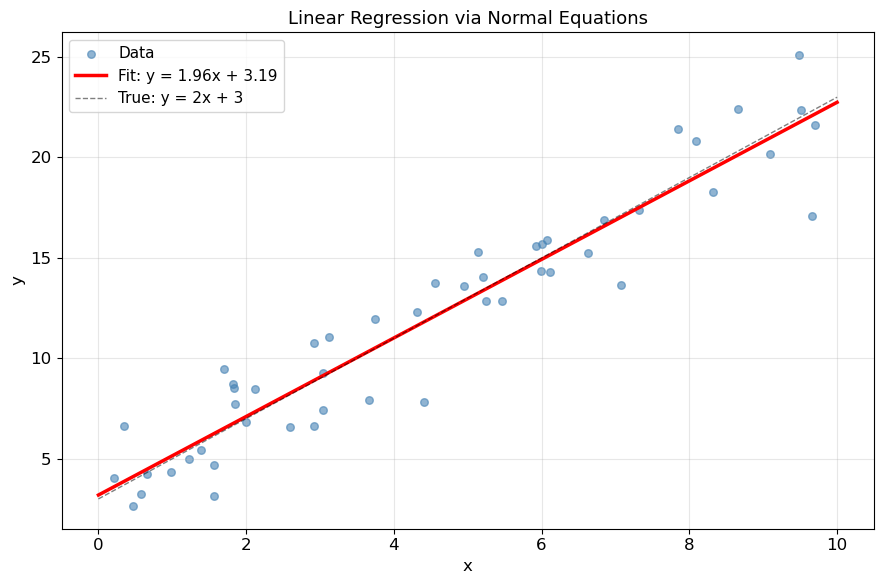

In [25]:
# Visualize the fit
fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(x_data, y_data, alpha=0.6, s=30, color='steelblue', label='Data')

x_line = np.linspace(0, 10, 100)
y_pred = w[0] * x_line + w[1]
ax.plot(x_line, y_pred, 'r-', linewidth=2.5,
        label=f'Fit: y = {w[0]:.2f}x + {w[1]:.2f}')
ax.plot(x_line, 2*x_line + 3, 'k--', linewidth=1, alpha=0.5, label='True: y = 2x + 3')

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Linear Regression via Normal Equations', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 5.7.2 Feature Independence and Multicollinearity

If features are linearly dependent, $X^T X$ becomes singular (or nearly so), making the normal equations ill-conditioned. This is **multicollinearity**, and it destabilizes regression.

In [26]:
np.random.seed(0)
n_samples = 100

# Independent features
x1 = np.random.randn(n_samples)
x2 = np.random.randn(n_samples)
X_good = np.column_stack([x1, x2, np.ones(n_samples)])

# Dependent features: x3 = 2*x1 + x2 (linearly dependent!)
x3 = 2 * x1 + x2
X_bad = np.column_stack([x1, x2, x3, np.ones(n_samples)])

print("=== Independent Features ===")
print(f"X shape: {X_good.shape}")
print(f"rank(X^T X) = {np.linalg.matrix_rank(X_good.T @ X_good)}")
print(f"cond(X^T X) = {np.linalg.cond(X_good.T @ X_good):.2f}")

print("\n=== Dependent Features (multicollinearity) ===")
print(f"X shape: {X_bad.shape}")
print(f"rank(X^T X) = {np.linalg.matrix_rank(X_bad.T @ X_bad)}")
print(f"cond(X^T X) = {np.linalg.cond(X_bad.T @ X_bad):.2e}  (huge => ill-conditioned!)")
print("\nThe nearly singular X^T X means the normal equations are unreliable.")
print("Solution: remove redundant features, or use regularization (Ridge, LASSO).")

=== Independent Features ===
X shape: (100, 3)
rank(X^T X) = 3
cond(X^T X) = 1.32

=== Dependent Features (multicollinearity) ===
X shape: (100, 4)
rank(X^T X) = 3
cond(X^T X) = 1.16e+16  (huge => ill-conditioned!)

The nearly singular X^T X means the normal equations are unreliable.
Solution: remove redundant features, or use regularization (Ridge, LASSO).


### 5.7.3 Least Squares for Overdetermined Systems

When $m > n$ (more equations than unknowns), the system is typically inconsistent. The least-squares solution $\hat{\mathbf{w}}$ minimizes $\|X\mathbf{w} - \mathbf{y}\|^2$, which is the best approximation even though $X\hat{\mathbf{w}} \neq \mathbf{y}$ exactly.

In [27]:
# Overdetermined: 5 data points, fitting a line (2 params)
X_over = np.array([[1, 1], [2, 1], [3, 1], [4, 1], [5, 1]], dtype=float)
y_over = np.array([2.1, 3.9, 6.2, 7.8, 10.1])

print(f"X: {X_over.shape}, y: {y_over.shape}")
print(f"rank(X) = {np.linalg.matrix_rank(X_over)}")
print(f"System is overdetermined (5 equations, 2 unknowns)")

# Least squares via normal equations
w_ls = np.linalg.solve(X_over.T @ X_over, X_over.T @ y_over)
print(f"\nLeast-squares solution: slope = {w_ls[0]:.4f}, intercept = {w_ls[1]:.4f}")

# Residuals
residuals = X_over @ w_ls - y_over
print(f"Residuals: {residuals.round(4)}")
print(f"||residual|| = {np.linalg.norm(residuals):.4f}  (nonzero => no exact solution)")

# Also available via np.linalg.lstsq
w_lstsq, _, _, _ = np.linalg.lstsq(X_over, y_over, rcond=None)
print(f"\nnp.linalg.lstsq: {w_lstsq.round(4)}  (same result)")

X: (5, 2), y: (5,)
rank(X) = 2
System is overdetermined (5 equations, 2 unknowns)

Least-squares solution: slope = 1.9900, intercept = 0.0500
Residuals: [-0.06  0.13 -0.18  0.21 -0.1 ]
||residual|| = 0.3271  (nonzero => no exact solution)

np.linalg.lstsq: [1.99 0.05]  (same result)


## 5.8 Exercises

Selected exercises from the chapter.

**Exercise 1:** Solve using substitution and verify: $x_1 + 2x_2 = 5$, $3x_1 - x_2 = 2$.

In [28]:
# Exercise 1: Your code here


**Exercise 6:** Use Gaussian elimination to solve: $x_1 + x_2 + x_3 = 6$, $2x_1 - x_2 + 3x_3 = 5$, $-x_1 + 2x_2 - x_3 = -1$.

In [29]:
# Exercise 6: Your code here


**Exercise 7:** Compute rank and nullity of $\begin{bmatrix} 1 & 2 & 3 \\ 2 & 4 & 6 \\ 3 & 6 & 9 \end{bmatrix}$.

In [30]:
# Exercise 7: Your code here


**Exercise 12:** Check linear dependence for $[1,2,3]^T$, $[4,5,6]^T$, $[7,8,9]^T$.

In [31]:
# Exercise 12: Your code here


---

## Exercise Solutions

In [32]:
# --- Solution: Exercise 1 ---
A = np.array([[1, 2], [3, -1]], dtype=float)
b = np.array([5, 2], dtype=float)
x = np.linalg.solve(A, b)
print(f"Solution: x1 = {x[0]:.4f}, x2 = {x[1]:.4f}")
print(f"Verify: A @ x = {A @ x}  (should be {b})")

Solution: x1 = 1.2857, x2 = 1.8571
Verify: A @ x = [5. 2.]  (should be [5. 2.])


In [33]:
# --- Solution: Exercise 6 ---
aug = sp.Matrix([
    [1,  1,  1, 6],
    [2, -1,  3, 5],
    [-1, 2, -1, -1]
])
rref, pivots = aug.rref()
print("RREF:")
sp.pprint(rref)
print(f"Solution: x1 = {rref[0,3]}, x2 = {rref[1,3]}, x3 = {rref[2,3]}")

RREF:
⎡1  0  0  19/3⎤
⎢             ⎥
⎢0  1  0  5/3 ⎥
⎢             ⎥
⎣0  0  1   -2 ⎦
Solution: x1 = 19/3, x2 = 5/3, x3 = -2


In [34]:
# --- Solution: Exercise 7 ---
A = np.array([[1,2,3],[2,4,6],[3,6,9]], dtype=float)
r = np.linalg.matrix_rank(A)
print(f"Rank: {r}, Nullity: {A.shape[1] - r}")
print("All rows are multiples of [1,2,3], so rank = 1.")

Rank: 1, Nullity: 2
All rows are multiples of [1,2,3], so rank = 1.


In [35]:
# --- Solution: Exercise 12 ---
M = sp.Matrix([[1,4,7],[2,5,8],[3,6,9]])
print(f"Rank: {M.rank()}, Vectors: {M.cols}")
print(f"Dependent? {M.rank() < M.cols}")
print("Null space:")
for v in M.nullspace():
    print(f"  {v.T}  => v1 + ({v[1]})*v2 + ({v[2]})*v3 = 0")

Rank: 2, Vectors: 3
Dependent? True
Null space:
  Matrix([[1, -2, 1]])  => v1 + (-2)*v2 + (1)*v3 = 0
